## Stock Analysis

In [99]:
import pandas as pd
import numpy as np

In [100]:
algo_df = pd.read_csv("../data/raw/algotrading_combined_dataset.csv")
funda_df = pd.read_csv("../data/raw/fundamental_research_dataset_large.csv")

In [101]:
algo_df

,Date,Ticker,Open,High,Low,Close,Volume
0,2015-01-01,AAPL,101.031849,101.329723,98.852354,101.197410,344567.0
1,2015-01-02,AAPL,100.866496,100.866496,99.568981,101.220064,310521.0
2,2015-01-05,AAPL,101.164489,101.176821,100.920124,101.339872,NaN
3,2015-01-06,AAPL,NaN,103.203859,102.287356,101.777905,295025.0
4,2015-01-07,AAPL,102.744728,104.050309,102.211701,102.090310,439080.0
...,...,...,...,...,...,...,...
32865,2021-08-02,AMZN,184.443237,185.375089,183.176491,183.087397,581356.0
32866,2017-01-24,AAPL,92.780364,93.092012,91.238510,NaN,754158.0
32867,2018-03-09,AMZN,98.074613,99.154029,96.203177,97.487616,76911.0
32868,2018-05-02,LTC/USD,103.443224,105.575739,103.159286,NaN,552764.0


#### 1. Identify all the top-performing stocks based on their overall return from the start to the end of the dataset.

In [102]:
algo_df['Ticker']

0           AAPL
1           AAPL
2           AAPL
3           AAPL
4           AAPL
          ...   
32865       AMZN
32866       AAPL
32867       AMZN
32868    LTC/USD
32869    ETH/USD
Name: Ticker, Length: 32870, dtype: object

In [103]:
# get unique rows of data - return array of unique rows
algo_df["Close"] = algo_df["Close"].ffill()
top_performer = []
tickers = algo_df['Ticker'].unique()

In [104]:
algo_df["Close"].isna().sum()

np.int64(0)

In [105]:
for ticker in tickers:
    stock = algo_df[algo_df["Ticker"] == ticker]
    overall_return = (stock["Close"].iloc[-1] - stock["Close"].iloc[0])/stock["Close"].iloc[0]
    top_performer.append({'Ticker': ticker,'Overall Performance' : overall_return})

# Top most performing stocks are:
return_df = pd.DataFrame(top_performer).sort_values('Overall Performance',ascending=False)
return_df = return_df.set_index("Ticker")


In [106]:
return_df

,Overall Performance
Ticker,
USD/CAD,0.822767
XRP/USD,0.810309
AAPL,0.809210
AUD/USD,0.789887
TSLA,0.773093
ETH/USD,0.627730
GBP/USD,0.626123
EUR/USD,0.451737
USD/JPY,-0.022091


<Axes: xlabel='Ticker'>

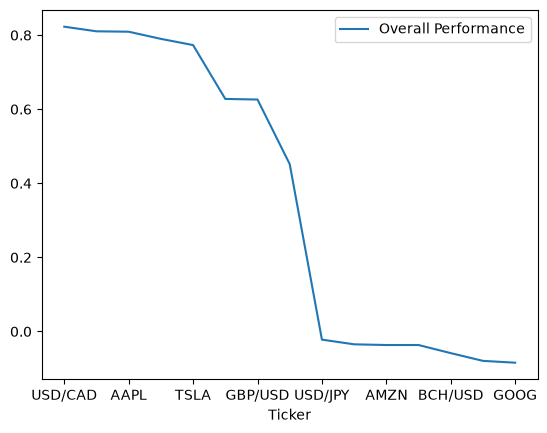

In [107]:
return_df.plot()
# return_df.plot(kind="bar")

<Axes: xlabel='Ticker'>

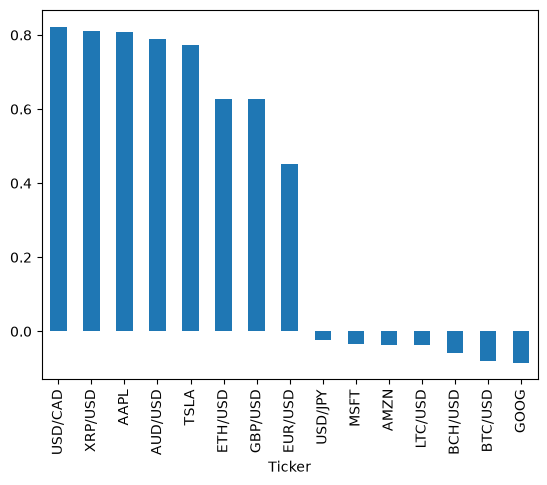

In [108]:
performance_series = return_df["Overall Performance"]

performance_series.plot(kind="bar")

In [109]:
type(return_df)
type(return_df.squeeze())

pandas.core.series.Series

In [110]:
teststock = algo_df[algo_df["Ticker"] == "AMZN"]
teststock["Close"]
#get the last col data
teststock["Close"].iloc[-1]
percentage = (teststock["Close"].iloc[-1] - teststock["Close"].iloc[-0])/teststock["Close"].iloc[0]
percentage

np.float64(-0.036658987641121826)

In [111]:
algo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32870 entries, 0 to 32869
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    32870 non-null  object 
 1   Ticker  32870 non-null  object 
 2   Open    31495 non-null  float64
 3   High    31302 non-null  float64
 4   Low     31090 non-null  float64
 5   Close   32870 non-null  float64
 6   Volume  30802 non-null  float64
dtypes: float64(5), object(2)
memory usage: 1.8+ MB


In [112]:
algo_df["Close"].isna().sum()

np.int64(0)

### 2. How many instances of daily price change greater than 5% occurred for each stock?

In [113]:
algo_df

,Date,Ticker,Open,High,Low,Close,Volume
0,2015-01-01,AAPL,101.031849,101.329723,98.852354,101.197410,344567.0
1,2015-01-02,AAPL,100.866496,100.866496,99.568981,101.220064,310521.0
2,2015-01-05,AAPL,101.164489,101.176821,100.920124,101.339872,NaN
3,2015-01-06,AAPL,NaN,103.203859,102.287356,101.777905,295025.0
4,2015-01-07,AAPL,102.744728,104.050309,102.211701,102.090310,439080.0
...,...,...,...,...,...,...,...
32865,2021-08-02,AMZN,184.443237,185.375089,183.176491,183.087397,581356.0
32866,2017-01-24,AAPL,92.780364,93.092012,91.238510,183.087397,754158.0
32867,2018-03-09,AMZN,98.074613,99.154029,96.203177,97.487616,76911.0
32868,2018-05-02,LTC/USD,103.443224,105.575739,103.159286,97.487616,552764.0


In [114]:
algo_df.isna()

,Date,Ticker,Open,High,Low,Close,Volume
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True
3,False,False,True,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
32865,False,False,False,False,False,False,False
32866,False,False,False,False,False,False,False
32867,False,False,False,False,False,False,False
32868,False,False,False,False,False,False,False


In [115]:
# first check hom many rows still have nan values
algo_df.isna().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32870 entries, 0 to 32869
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    32870 non-null  bool 
 1   Ticker  32870 non-null  bool 
 2   Open    32870 non-null  bool 
 3   High    32870 non-null  bool 
 4   Low     32870 non-null  bool 
 5   Close   32870 non-null  bool 
 6   Volume  32870 non-null  bool 
dtypes: bool(7)
memory usage: 224.8 KB


In [116]:
algo_df.ffill(inplace=True)

In [117]:
algo_df.isna()

,Date,Ticker,Open,High,Low,Close,Volume
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
32865,False,False,False,False,False,False,False
32866,False,False,False,False,False,False,False
32867,False,False,False,False,False,False,False
32868,False,False,False,False,False,False,False


In [118]:
algo_df.isna().sum()

Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [ ]:
# multiple ticker
### 2. How many instances of daily price change greater than 5% occurred for each stock?

# Today's Close − Yesterday's Close
# ----------------------------------
# Yesterday's Close
# Calculation:

# (110 - 100) / 100
# = 0.10

# So:
# Daily change = 10%
algo_df['Daily change'] = algo_df['Close'].pct_change()

# Is daily change > 5% ? - return True or False
algo_df['High change'] = algo_df['Daily change'] > 0.05
algo_df
tickers = algo_df['Ticker'].unique()
occurance = {}
for ticker in tickers:
    high_change_tickers = algo_df[(algo_df['Ticker'] == ticker) & (algo_df['High change'] == True)]
    occurance[ticker] = high_change_tickers.shape[0]

occurance

# now plot a chart  of occurance variable = we have to convert this dicionary to a list and then to a  data frame
df = pd.DataFrame(list(occurance.items()), columns = ["Ticker", "Value"])
df.set_index("Ticker",inplace=True)
df
# df.plot()

,Value
Ticker,
AAPL,37
GOOG,50
MSFT,34
AMZN,43
TSLA,33
EUR/USD,35
GBP/USD,42
USD/JPY,46
AUD/USD,41


In [ ]:
# single ticker
# THIS IS THE DATA where change of more than 5% occurred
algo_df[(algo_df['Ticker'] == "USD/JPY") & (algo_df['High change'] == True)].shape[0]

46

In [130]:
# now check data  > .05 %
algo_df[algo_df['Daily change']  > 0.05]
algo_df['High change'] = algo_df['Daily change'] > 0.05


In [133]:
# unique ticker name
tickers = algo_df['Ticker'].unique()

### 3. Calculate the number of times each stock's price increased in the first quarter.

In [172]:
algo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32870 entries, 0 to 32869
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          32870 non-null  datetime64[ns]
 1   Ticker        32870 non-null  object        
 2   Open          32870 non-null  float64       
 3   High          32870 non-null  float64       
 4   Low           32870 non-null  float64       
 5   Close         32870 non-null  float64       
 6   Volume        32870 non-null  float64       
 7   Daily change  32869 non-null  float64       
 8   High change   32870 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(6), object(1)
memory usage: 2.0+ MB


In [ ]:
algo_df
type(algo_df['Date'])
algo_df['Date'] = pd.to_datetime(algo_df['Date'])
algo_df['Date'].dtype

dtype('<M8[ns]')

In [174]:
algo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32870 entries, 0 to 32869
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          32870 non-null  datetime64[ns]
 1   Ticker        32870 non-null  object        
 2   Open          32870 non-null  float64       
 3   High          32870 non-null  float64       
 4   Low           32870 non-null  float64       
 5   Close         32870 non-null  float64       
 6   Volume        32870 non-null  float64       
 7   Daily change  32869 non-null  float64       
 8   High change   32870 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(6), object(1)
memory usage: 2.0+ MB


<Axes: xlabel='Ticker'>

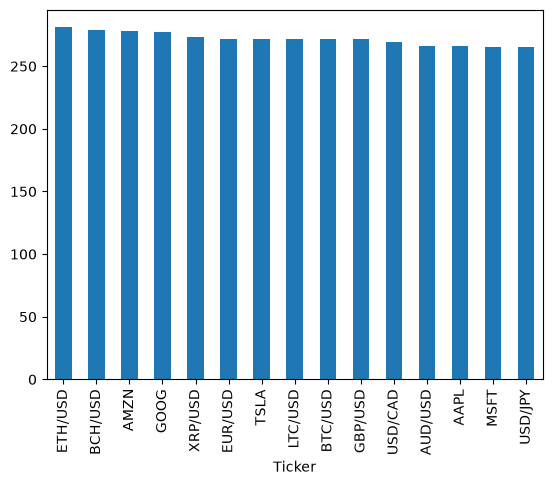

In [191]:
first_quarter = algo_df[algo_df['Date'].dt.month.isin([1,2,3])]
first_quarter.sample(20)
first_quarter = first_quarter[first_quarter['Close'] > first_quarter['Open']]
increase_counts = first_quarter['Ticker'].value_counts()
increase_counts.plot(kind="bar")

